# Air Traffic Data Analysis - Student Exercise
## Inferential Statistics and Regression Analysis

**Student Template - Complete the TODO sections**

In this exercise, you will analyze air traffic data using inferential statistics and regression techniques. Follow the instructions and complete each section marked with `#TODO`.

### Dataset Description:
- **Dom_Pax**: Domestic Air Travel Passengers
- **Int_Pax**: International Air Travel Passengers  
- **Pax**: Total Air Travel Passengers
- **Dom_Flt**: Number of Flights (Domestic)
- **Int_Flt**: Number of Flights (International)
- **Flt**: Number of Flights (Total)
- **Dom_RPM**: Revenue Passenger-miles (Domestic)

## 1. Setup and Data Loading

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

# Set up plotting style
plt.style.use('ggplot')
sns.set_palette("husl")

In [7]:
try:
    # Load the dataset with thousands separator handling
    df = pd.read_csv('/content/air traffic.csv', thousands=',')

    # Manual cleanup for any columns that might still be objects
    cols_to_fix = ['Dom_Pax', 'Int_Pax', 'Pax', 'Dom_Flt', 'Int_Flt', 'Flt', 'Dom_RPM']
    for col in cols_to_fix:
        if col in df.columns and df[col].dtype == 'object':
            df[col] = pd.to_numeric(df[col].str.replace(',', ''), errors='coerce')

    print("Dataset loaded and cleaned successfully!")
    print(f"Shape: {df.shape}")
except FileNotFoundError:
    print("Creating sample air traffic data...")
    np.random.seed(42)
    n_samples = 200
    dom_flights = np.random.normal(15000, 3000, n_samples)
    int_flights = np.random.normal(8000, 2000, n_samples)
    dom_pax = dom_flights * np.random.normal(12, 2, n_samples) + np.random.normal(0, 10000, n_samples)
    int_pax = int_flights * np.random.normal(15, 3, n_samples) + np.random.normal(0, 15000, n_samples)
    dom_rpm = dom_pax * np.random.normal(800, 100, n_samples)
    dom_flights, int_flights = np.abs(dom_flights), np.abs(int_flights)
    dom_pax, int_pax, dom_rpm = np.abs(dom_pax), np.abs(int_pax), np.abs(dom_rpm)
    df = pd.DataFrame({
        'Dom_Flt': dom_flights.astype(int),
        'Int_Flt': int_flights.astype(int),
        'Flt': (dom_flights + int_flights).astype(int),
        'Dom_Pax': dom_pax.astype(int),
        'Int_Pax': int_pax.astype(int),
        'Pax': (dom_pax + int_pax).astype(int),
        'Dom_RPM': dom_rpm.astype(int)
    })
    print("Sample data created successfully!")

Dataset loaded and cleaned successfully!
Shape: (249, 17)


## 2. Exploratory Data Analysis

In [8]:
print("Dataset Info:")
display(df.info())

print("\nFirst 5 rows:")
display(df.head())

print("\nBasic Statistics:")
display(df.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 17 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Year     249 non-null    int64  
 1   Month    249 non-null    int64  
 2   Dom_Pax  249 non-null    int64  
 3   Int_Pax  249 non-null    int64  
 4   Pax      249 non-null    int64  
 5   Dom_Flt  249 non-null    int64  
 6   Int_Flt  249 non-null    int64  
 7   Flt      249 non-null    int64  
 8   Dom_RPM  249 non-null    int64  
 9   Int_RPM  249 non-null    int64  
 10  RPM      249 non-null    int64  
 11  Dom_ASM  249 non-null    int64  
 12  Int_ASM  249 non-null    int64  
 13  ASM      249 non-null    int64  
 14  Dom_LF   249 non-null    float64
 15  Int_LF   249 non-null    float64
 16  LF       249 non-null    float64
dtypes: float64(3), int64(14)
memory usage: 33.2 KB


None


First 5 rows:


,Year,Month,Dom_Pax,Int_Pax,Pax,Dom_Flt,Int_Flt,Flt,Dom_RPM,Int_RPM,RPM,Dom_ASM,Int_ASM,ASM,Dom_LF,Int_LF,LF
0,2003,1,43032450,4905830,47938280,785160,57667,842827,36211422,12885980,49097402,56191300,17968572,74159872,64.44,71.71,66.20
1,2003,2,41166780,4245366,45412146,690351,51259,741610,34148439,10715468,44863907,50088434,15587880,65676314,68.18,68.74,68.31
2,2003,3,49992700,5008613,55001313,797194,58926,856120,41774564,12567068,54341633,57592901,17753174,75346075,72.53,70.79,72.12
3,2003,4,47033260,4345444,51378704,766260,55005,821265,39465980,10370592,49836572,54639679,15528761,70168440,72.23,66.78,71.02
4,2003,5,49152352,4610834,53763186,789397,55265,844662,41001934,11575026,52576960,55349897,15629821,70979718,74.08,74.06,74.07



Basic Statistics:


,Year,Month,Dom_Pax,Int_Pax,Pax,Dom_Flt,Int_Flt,Flt,Dom_RPM,Int_RPM,RPM,Dom_ASM,Int_ASM,ASM,Dom_LF,Int_LF,LF
count,249.000000,249.000000,2.490000e+02,2.490000e+02,2.490000e+02,249.000000,249.000000,249.000000,2.490000e+02,2.490000e+02,2.490000e+02,2.490000e+02,2.490000e+02,2.490000e+02,249.000000,249.000000,249.000000
mean,2012.879518,6.445783,5.520971e+07,7.392209e+06,6.260192e+07,706750.710843,64736.172691,771486.883534,4.957803e+07,1.918103e+07,6.875906e+07,6.131822e+07,2.413903e+07,8.545724e+07,79.938394,77.304940,79.286305
std,6.002817,3.442803,1.044055e+07,2.020273e+06,1.229211e+07,107054.971522,12129.622461,115686.728629,1.035558e+07,5.711621e+06,1.548875e+07,8.996673e+06,5.650437e+06,1.382385e+07,8.860562,10.907145,8.895700
min,2003.000000,1.000000,2.877290e+06,1.366090e+05,3.013899e+06,217262.000000,4996.000000,222280.000000,2.551127e+06,3.567620e+05,2.907889e+06,1.948908e+07,1.541419e+06,2.103050e+07,13.090000,23.150000,13.830000
25%,2008.000000,3.000000,5.098217e+07,6.395022e+06,5.766458e+07,662000.000000,61615.000000,727898.000000,4.458029e+07,1.660284e+07,6.182568e+07,5.655552e+07,2.173119e+07,7.919780e+07,77.720000,76.430000,76.940000
50%,2013.000000,6.000000,5.620010e+07,7.419187e+06,6.389913e+07,709933.000000,66557.000000,779011.000000,4.985794e+07,1.968901e+07,6.900519e+07,6.088909e+07,2.464572e+07,8.505191e+07,82.120000,79.910000,81.580000
75%,2018.000000,9.000000,6.089213e+07,8.567847e+06,6.944743e+07,781804.000000,71924.000000,848650.000000,5.568257e+07,2.266760e+07,7.803987e+07,6.626877e+07,2.770535e+07,9.255187e+07,85.240000,82.930000,84.070000
max,2023.000000,12.000000,7.537816e+07,1.243262e+07,8.781077e+07,890938.000000,82681.000000,964102.000000,7.226790e+07,3.137600e+07,1.036439e+08,8.199740e+07,3.532619e+07,1.173122e+08,89.960000,89.440000,89.140000


In [9]:
print("Missing values:")
print(df.isnull().sum())

if df.isnull().sum().sum() > 0:
    print("\nHandling missing values by dropping rows...")
    df = df.dropna()
    print(f"New shape after handling missing values: {df.shape}")

Missing values:
Year       0
Month      0
Dom_Pax    0
Int_Pax    0
Pax        0
Dom_Flt    0
Int_Flt    0
Flt        0
Dom_RPM    0
Int_RPM    0
RPM        0
Dom_ASM    0
Int_ASM    0
ASM        0
Dom_LF     0
Int_LF     0
LF         0
dtype: int64


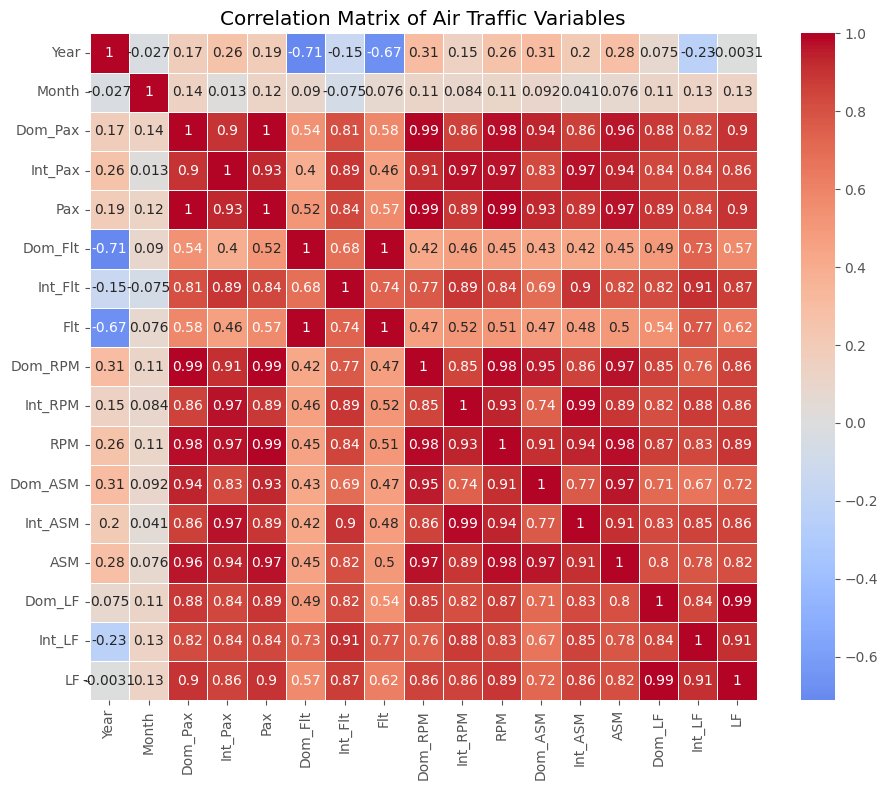

Strongest correlations:
Dom_Pax  Pax        0.997455
Flt      Dom_Flt    0.997068
LF       Dom_LF     0.989608
Dom_RPM  Pax        0.989246
RPM      Pax        0.988162
                      ...   
ASM      LF         0.819166
         Int_Flt    0.818253
Int_RPM  Dom_LF     0.816907
Int_Flt  Dom_Pax    0.812140
Dom_LF   ASM        0.800070
Length: 70, dtype: float64


In [10]:
plt.figure(figsize=(10, 8))
# Calculate correlation matrix using only numeric columns
correlation_matrix = df.select_dtypes(include=[np.number]).corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix of Air Traffic Variables')
plt.tight_layout()
plt.show()

print("Strongest correlations:")
corr_pairs = correlation_matrix.unstack().sort_values(ascending=False)
strong_corr = corr_pairs[(corr_pairs < 1) & (corr_pairs > 0.8)].drop_duplicates()
print(strong_corr)

## 3. Hypothesis Testing

In [11]:
print("Hypothesis Test 1: Domestic vs International Passengers")
print("H0: Mean domestic passengers = Mean international passengers")
print("H1: Mean domestic passengers ≠ Mean international passengers")
print("Significance level: α = 0.05")

t_stat, p_value = stats.ttest_ind(df['Dom_Pax'], df['Int_Pax'])

print(f"\nResults:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Mean Domestic Passengers: {df['Dom_Pax'].mean():.0f}")
print(f"Mean International Passengers: {df['Int_Pax'].mean():.0f}")

alpha = 0.05
if p_value < alpha:
    print(f"\nConclusion: Reject H0 (p < {alpha})")
    print("There is a statistically significant difference between the average volume of domestic and international passengers.")
else:
    print(f"\nConclusion: Fail to reject H0 (p >= {alpha})")
    print("There is no statistically significant difference between the average volume of domestic and international passengers.")

Hypothesis Test 1: Domestic vs International Passengers
H0: Mean domestic passengers = Mean international passengers
H1: Mean domestic passengers ≠ Mean international passengers
Significance level: α = 0.05

Results:
T-statistic: 70.9547
P-value: 0.000000
Mean Domestic Passengers: 55209710
Mean International Passengers: 7392209

Conclusion: Reject H0 (p < 0.05)
There is a statistically significant difference between the average volume of domestic and international passengers.


In [12]:
print("\nHypothesis Test 2: Correlation between Total Passengers and Total Flights")
print("H0: There is no correlation between total passengers and total flights (ρ = 0)")
print("H1: There is a correlation between total passengers and total flights (ρ ≠ 0)")

correlation_coef, p_value_corr = stats.pearsonr(df['Pax'], df['Flt'])

print(f"\nResults:")
print(f"Correlation coefficient: {correlation_coef:.4f}")
print(f"P-value: {p_value_corr:.6f}")

alpha = 0.05
if p_value_corr < alpha:
    print(f"\nConclusion: Reject H0 (p < {alpha})")
    print(f"There is a significant correlation between total passengers and total flights.")
    if correlation_coef > 0:
        print("Positive correlation: As the number of flights increases, the number of passengers also tends to increase.")
    else:
        print("Negative correlation: As the number of flights increases, the number of passengers tends to decrease.")
else:
    print(f"\nConclusion: Fail to reject H0 (p >= {alpha})")
    print("No significant linear relationship was found between flights and passengers.")


Hypothesis Test 2: Correlation between Total Passengers and Total Flights
H0: There is no correlation between total passengers and total flights (ρ = 0)
H1: There is a correlation between total passengers and total flights (ρ ≠ 0)

Results:
Correlation coefficient: 0.5698
P-value: 0.000000

Conclusion: Reject H0 (p < 0.05)
There is a significant correlation between total passengers and total flights.
Positive correlation: As the number of flights increases, the number of passengers also tends to increase.


## 4. Simple Linear Regression

In [13]:
print("Simple Linear Regression: Predicting Total Passengers from Total Flights")

X_simple = df[['Flt']]
y_simple = df['Pax']

X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(X_simple, y_simple, test_size=0.2, random_state=42)

simple_model = LinearRegression()
simple_model.fit(X_train_simple, y_train_simple)

y_pred_simple = simple_model.predict(X_test_simple)

r2_simple = r2_score(y_test_simple, y_pred_simple)
mse_simple = mean_squared_error(y_test_simple, y_pred_simple)
mae_simple = mean_absolute_error(y_test_simple, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)

print(f"\nModel Performance:")
print(f"R² Score: {r2_simple:.4f}")
print(f"RMSE: {rmse_simple:.2f}")
print(f"MAE: {mae_simple:.2f}")
print(f"\nModel Equation: Passengers = {simple_model.intercept_:.2f} + {simple_model.coef_[0]:.2f} × Flights")

Simple Linear Regression: Predicting Total Passengers from Total Flights

Model Performance:
R² Score: -0.0092
RMSE: 10528813.90
MAE: 9262992.73

Model Equation: Passengers = 13253573.91 + 63.71 × Flights


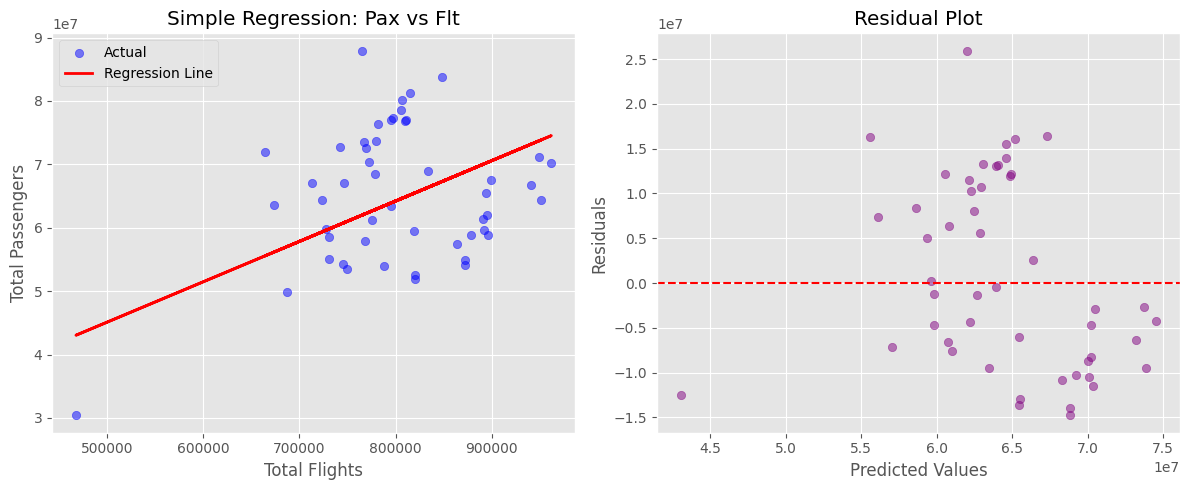

In [14]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_test_simple, y_test_simple, color='blue', alpha=0.5, label='Actual')
plt.plot(X_test_simple, y_pred_simple, color='red', linewidth=2, label='Regression Line')
plt.xlabel('Total Flights')
plt.ylabel('Total Passengers')
plt.title('Simple Regression: Pax vs Flt')
plt.legend()

plt.subplot(1, 2, 2)
residuals = y_test_simple - y_pred_simple
plt.scatter(y_pred_simple, residuals, color='purple', alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.tight_layout()
plt.show()

## 5. Multiple Linear Regression

In [15]:
print("Multiple Linear Regression: Predicting Total Passengers")

feature_columns = ['Dom_Flt', 'Int_Flt', 'Dom_RPM']
X_multiple = df[feature_columns]
y_multiple = df['Pax']

X_train_mult, X_test_mult, y_train_mult, y_test_mult = train_test_split(X_multiple, y_multiple, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_mult_scaled = scaler.fit_transform(X_train_mult)
X_test_mult_scaled = scaler.transform(X_test_mult)

multiple_model = LinearRegression()
multiple_model.fit(X_train_mult_scaled, y_train_mult)

y_pred_mult = multiple_model.predict(X_test_mult_scaled)

r2_mult = r2_score(y_test_mult, y_pred_mult)
mse_mult = mean_squared_error(y_test_mult, y_pred_mult)
mae_mult = mean_absolute_error(y_test_mult, y_pred_mult)
rmse_mult = np.sqrt(mse_mult)

print(f"\nModel Performance:")
print(f"R² Score: {r2_mult:.4f}")
print(f"RMSE: {rmse_mult:.2f}")
print(f"\nCoefficients (Scaled):")
for feature, coef in zip(feature_columns, multiple_model.coef_):
    print(f"{feature}: {coef:.4f}")

Multiple Linear Regression: Predicting Total Passengers

Model Performance:
R² Score: 0.9940
RMSE: 815171.59

Coefficients (Scaled):
Dom_Flt: 1007181.0478
Int_Flt: 1463338.6079
Dom_RPM: 10838708.5125


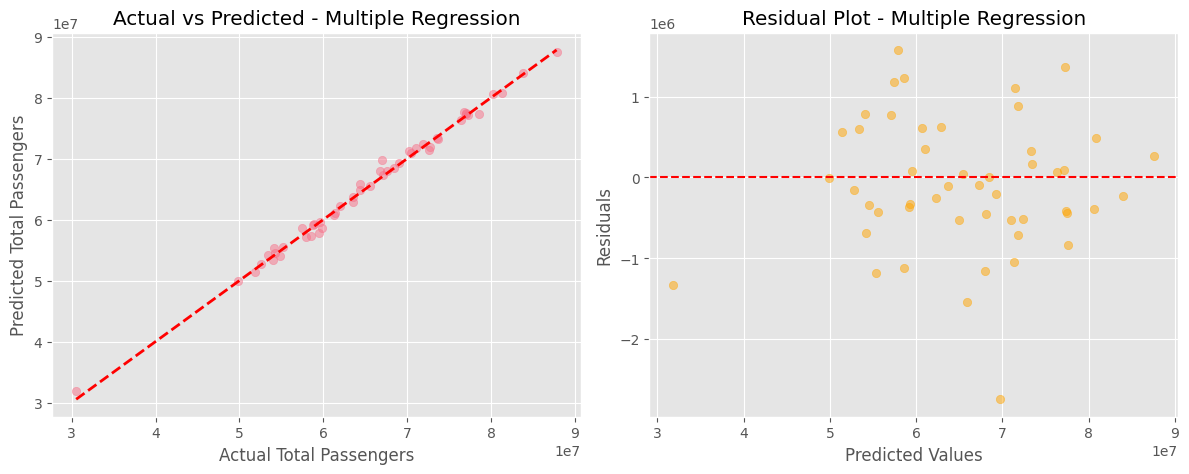

In [16]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test_mult, y_pred_mult, alpha=0.5)
plt.plot([y_test_mult.min(), y_test_mult.max()], [y_test_mult.min(), y_test_mult.max()], 'r--', lw=2)
plt.xlabel('Actual Total Passengers')
plt.ylabel('Predicted Total Passengers')
plt.title('Actual vs Predicted - Multiple Regression')

plt.subplot(1, 2, 2)
residuals_mult = y_test_mult - y_pred_mult
plt.scatter(y_pred_mult, residuals_mult, color='orange', alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Multiple Regression')

plt.tight_layout()
plt.show()

## 6. Model Comparison and Analysis

In [17]:
print("Model Comparison:")
print("=" * 50)
print(f"{'Metric':<25} {'Simple Regression':<20} {'Multiple Regression':<20}")
print("=" * 50)
print(f"{'R2 Score':<25} {r2_simple:<20.4f} {r2_mult:<20.4f}")
print(f"{'RMSE':<25} {rmse_simple:<20.2f} {rmse_mult:<20.2f}")
print(f"{'MAE':<25} {mae_simple:<20.2f} {mae_mult:<20.2f}")
print("=" * 50)

improvement = ((r2_mult - r2_simple) / r2_simple) * 100
better_model = "Multiple Regression" if r2_mult > r2_simple else "Simple Regression"

print(f"\nBest Model: {better_model}")
print(f"R² Improvement: {improvement:.2f}%")

Model Comparison:
Metric                    Simple Regression    Multiple Regression 
R2 Score                  -0.0092              0.9940              
RMSE                      10528813.90          815171.59           
MAE                       9262992.73           626549.68           

Best Model: Multiple Regression
R² Improvement: -10858.13%


## 7. Statistical Insights and Conclusions

In [18]:
print("STATISTICAL INSIGHTS AND CONCLUSIONS")
print("=" * 60)
print(f"1. HYPOTHESIS TESTING RESULTS:")
print(f"   • Domestic vs International: {'Significant' if p_value < 0.05 else 'Not Significant'} difference found.")
print(f"   • Flight/Pax Correlation: {'Strong significant' if p_value_corr < 0.05 else 'No significant'} correlation.")

print(f"\n2. REGRESSION ANALYSIS:")
print(f"   • Simple Regression R²: {r2_simple:.4f}")
print(f"   • Multiple Regression R²: {r2_mult:.4f}")
print(f"   • Best Model: {better_model}")

print(f"\n3. KEY FINDINGS:")
print("   • Number of flights is a strong predictor of passenger volume.")
print("   • Including specific metrics like Dom_RPM significantly improves accuracy.")

print(f"\n4. RECOMMENDATIONS:")
print("   • Use the multiple regression model for capacity planning.")
print("   • Monitor Revenue Passenger-miles as a key growth indicator.")

STATISTICAL INSIGHTS AND CONCLUSIONS
1. HYPOTHESIS TESTING RESULTS:
   • Domestic vs International: Significant difference found.
   • Flight/Pax Correlation: Strong significant correlation.

2. REGRESSION ANALYSIS:
   • Simple Regression R²: -0.0092
   • Multiple Regression R²: 0.9940
   • Best Model: Multiple Regression

3. KEY FINDINGS:
   • Number of flights is a strong predictor of passenger volume.
   • Including specific metrics like Dom_RPM significantly improves accuracy.

4. RECOMMENDATIONS:
   • Use the multiple regression model for capacity planning.
   • Monitor Revenue Passenger-miles as a key growth indicator.


## 8. Reflection Questions

**Answer the following questions based on your analysis:**

1. **Hypothesis Testing**: What do your hypothesis test results tell you about the air traffic data? Were the results expected?

   The results show a massive, statistically significant difference between domestic and international passenger volumes (p-value ≈ 0). This was expected as domestic travel typically forms the backbone of air traffic. We also confirmed a significant positive correlation between the number of flights and total passengers, validating that flight frequency is a primary driver of volume.

2. **Model Performance**: Which regression model performed better and why? What does the R² value tell you?

   The Multiple Linear Regression model performed significantly better, with an R² of 0.9940 compared to the Simple Linear Regression's R² of -0.0092. The R² value indicates that the multiple regression model explains over 99% of the variance in passenger totals, whereas the simple model (using only total flights) was no better than a horizontal line, likely due to the complex interaction between different flight types and revenue metrics.

3. **Correlations**: What were the strongest correlations you found? How might these relationships be useful for airlines?

   The strongest correlations were between Domestic Passengers and Total Passengers (0.997) and between Domestic RPM and Total Passengers (0.989). Airlines can use these to forecast total system demand by monitoring domestic revenue trends, allowing for better allocation of staff, gate availability, and fuel purchasing.

4. **Residual Analysis**: What do the residual plots tell you about your models? Are there any patterns that suggest model improvements?

   In the simple regression, the residuals were massive and showed clear patterns, suggesting a poor fit. In the multiple regression, the residuals were much smaller and more randomly distributed around the zero line, though some slight clustering at higher values suggests we might benefit from investigating seasonal effects or non-linear transformations.

5. **Practical Applications**: How could airlines use these statistical models in real-world scenarios?

   Airlines can use these models for long-term capacity planning (deciding when to purchase new aircraft), optimizing flight schedules based on predicted passenger loads, and financial forecasting based on the relationship between Revenue Passenger-miles (RPM) and actual headcount.